# Option Pricing and Greeks

Options are contracts whose value depends on an underlying asset. This notebook introduces Black-Scholes option pricing and the main option Greeks: delta, gamma, theta, vega, and rho.

Abbreviations used in this notebook:

- **BSM**: Black-Scholes-Merton, a model for pricing European options.
- **Call**: an option giving the right to buy the underlying at a strike price.
- **Put**: an option giving the right to sell the underlying at a strike price.
- **ITM**: In the money, an option with immediate exercise value.
- **ATM**: At the money, an option with strike near the current underlying price.
- **OTM**: Out of the money, an option with no immediate exercise value.

## 1. Intuition

An option price is driven by five main inputs:

- **Underlying price**: the current price of the stock or asset.
- **Strike price**: the fixed price at which the option can be exercised.
- **Time to expiration**: more time usually means more optionality.
- **Volatility**: higher expected movement usually makes options more valuable.
- **Interest rate**: affects the present value of future exercise cash flows.

The Greeks measure sensitivity. They answer questions such as: how much does the option price change when the stock moves, volatility changes, time passes, or rates move?

## 2. Mathematics

**Black-Scholes inputs:**

$$
d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}
$$

Where:

- $d_1$ = standardized distance between current price and strike after adjusting for time, rates, and volatility
- $S$ = current underlying price
- $K$ = strike price
- $r$ = continuously compounded risk-free rate
- $\sigma$ = annualized volatility of the underlying asset
- $T$ = time to expiration in years

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

Where:

- $d_2$ = second Black-Scholes standardized term
- $d_1$ = first Black-Scholes standardized term
- $\sigma$ = annualized volatility
- $T$ = time to expiration in years

**European call price:**

$$
C = S N(d_1) - K e^{-rT} N(d_2)
$$

Where:

- $C$ = European call option price
- $S$ = current underlying price
- $K$ = strike price
- $r$ = continuously compounded risk-free rate
- $T$ = time to expiration in years
- $N(d)$ = cumulative standard normal distribution function
- $e$ = Euler's number used for continuous compounding

**European put price:**

$$
P = K e^{-rT} N(-d_2) - S N(-d_1)
$$

Where:

- $P$ = European put option price
- $S$ = current underlying price
- $K$ = strike price
- $r$ = continuously compounded risk-free rate
- $T$ = time to expiration in years
- $N(d)$ = cumulative standard normal distribution function

**Delta:**

$$
\Delta_{call} = N(d_1)
$$

Where:

- $\Delta_{call}$ = call delta, sensitivity to a one-unit change in the underlying price
- $N(d_1)$ = cumulative standard normal distribution evaluated at $d_1$

**Gamma:**

$$
\Gamma = \frac{N'(d_1)}{S\sigma\sqrt{T}}
$$

Where:

- $\Gamma$ = gamma, sensitivity of delta to a one-unit change in the underlying price
- $N'(d_1)$ = standard normal probability density evaluated at $d_1$
- $S$ = current underlying price
- $\sigma$ = annualized volatility
- $T$ = time to expiration in years

**Vega:**

$$
Vega = S N'(d_1)\sqrt{T}
$$

Where:

- $Vega$ = sensitivity to a 1.00, or 100 percentage point, change in volatility
- $S$ = current underlying price
- $N'(d_1)$ = standard normal probability density evaluated at $d_1$
- $T$ = time to expiration in years

## 3. Implementation

We implement Black-Scholes directly with numpy and the standard library. The prices are for European options, which can only be exercised at expiration.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

def norm_pdf(x):
    return np.exp(-0.5 * np.asarray(x) ** 2) / math.sqrt(2 * math.pi)

def norm_cdf(x):
    erf = np.vectorize(math.erf)
    return 0.5 * (1 + erf(np.asarray(x) / math.sqrt(2)))

def black_scholes_terms(spot, strike, rate, volatility, time_to_expiry):
    sqrt_t = np.sqrt(time_to_expiry)
    d1 = (np.log(spot / strike) + (rate + 0.5 * volatility ** 2) * time_to_expiry) / (volatility * sqrt_t)
    d2 = d1 - volatility * sqrt_t
    return d1, d2

def black_scholes_price(spot, strike, rate, volatility, time_to_expiry, option_type="call"):
    d1, d2 = black_scholes_terms(spot, strike, rate, volatility, time_to_expiry)
    discount = np.exp(-rate * time_to_expiry)

    if option_type == "call":
        return spot * norm_cdf(d1) - strike * discount * norm_cdf(d2)
    if option_type == "put":
        return strike * discount * norm_cdf(-d2) - spot * norm_cdf(-d1)
    raise ValueError("option_type must be 'call' or 'put'")

def black_scholes_greeks(spot, strike, rate, volatility, time_to_expiry, option_type="call"):
    d1, d2 = black_scholes_terms(spot, strike, rate, volatility, time_to_expiry)
    pdf_d1 = norm_pdf(d1)
    discount = np.exp(-rate * time_to_expiry)

    if option_type == "call":
        delta = norm_cdf(d1)
        theta = (-(spot * pdf_d1 * volatility) / (2 * np.sqrt(time_to_expiry))
                 - rate * strike * discount * norm_cdf(d2))
        rho = strike * time_to_expiry * discount * norm_cdf(d2)
    elif option_type == "put":
        delta = norm_cdf(d1) - 1
        theta = (-(spot * pdf_d1 * volatility) / (2 * np.sqrt(time_to_expiry))
                 + rate * strike * discount * norm_cdf(-d2))
        rho = -strike * time_to_expiry * discount * norm_cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    gamma = pdf_d1 / (spot * volatility * np.sqrt(time_to_expiry))
    vega = spot * pdf_d1 * np.sqrt(time_to_expiry)

    return {
        "delta": delta,
        "gamma": gamma,
        "theta_per_year": theta,
        "theta_per_day": theta / 252,
        "vega_per_1_vol_point": vega / 100,
        "rho_per_1_rate_point": rho / 100,
    }

In [2]:
assumptions = {
    "spot": 100.0,
    "strike": 100.0,
    "rate": 0.025,
    "volatility": 0.22,
    "time_to_expiry": 0.50,
}

rows = []
for option_type in ["call", "put"]:
    price = black_scholes_price(**assumptions, option_type=option_type)
    greeks = black_scholes_greeks(**assumptions, option_type=option_type)
    rows.append({"option_type": option_type, "price": price, **greeks})

option_summary = pd.DataFrame(rows).set_index("option_type")
option_summary.style.format({
    "price": "{:,.2f}",
    "delta": "{:,.3f}",
    "gamma": "{:,.4f}",
    "theta_per_year": "{:,.2f}",
    "theta_per_day": "{:,.4f}",
    "vega_per_1_vol_point": "{:,.3f}",
    "rho_per_1_rate_point": "{:,.3f}",
})

,price,delta,gamma,theta_per_year,theta_per_day,vega_per_1_vol_point,rho_per_1_rate_point
option_type,,,,,,,
call,6.80,0.563,0.0253,-7.37,-0.0292,0.279,0.247
put,5.56,-0.437,0.0253,-4.90,-0.0194,0.279,-0.246


The table scales vega and rho to practical units. `vega_per_1_vol_point` is the approximate option price change for a one percentage point volatility move, such as 22% to 23%. `rho_per_1_rate_point` is the approximate price change for a one percentage point interest-rate move.

## 4. Visualization

Greeks are easiest to understand by changing one input at a time. The charts below show how call price, delta, gamma, and vega change across underlying prices.

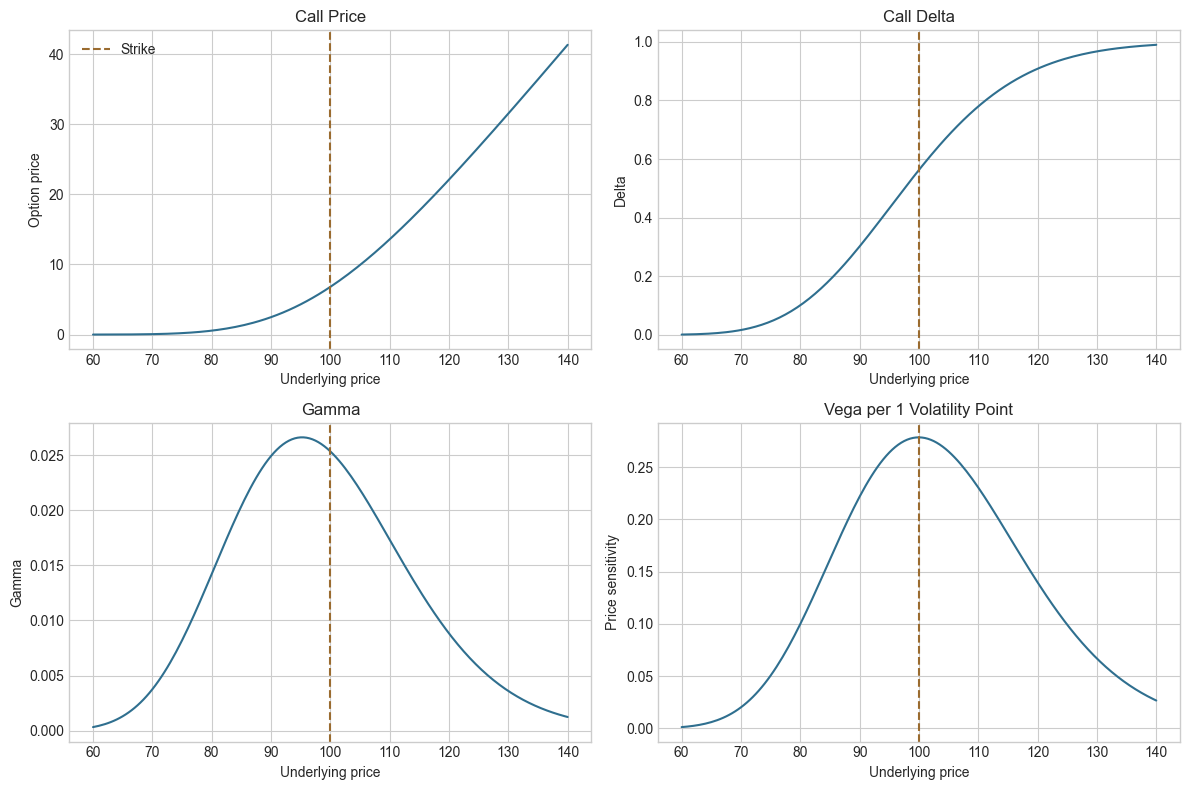

In [3]:
spots = np.linspace(60, 140, 161)
call_prices = black_scholes_price(spots, assumptions["strike"], assumptions["rate"], assumptions["volatility"], assumptions["time_to_expiry"], "call")
call_greeks = black_scholes_greeks(spots, assumptions["strike"], assumptions["rate"], assumptions["volatility"], assumptions["time_to_expiry"], "call")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(spots, call_prices, color="#2f6f8f")
axes[0, 0].axvline(assumptions["strike"], color="#9a6b2f", linestyle="--", label="Strike")
axes[0, 0].set_title("Call Price")
axes[0, 0].set_xlabel("Underlying price")
axes[0, 0].set_ylabel("Option price")
axes[0, 0].legend()

axes[0, 1].plot(spots, call_greeks["delta"], color="#2f6f8f")
axes[0, 1].axvline(assumptions["strike"], color="#9a6b2f", linestyle="--")
axes[0, 1].set_title("Call Delta")
axes[0, 1].set_xlabel("Underlying price")
axes[0, 1].set_ylabel("Delta")

axes[1, 0].plot(spots, call_greeks["gamma"], color="#2f6f8f")
axes[1, 0].axvline(assumptions["strike"], color="#9a6b2f", linestyle="--")
axes[1, 0].set_title("Gamma")
axes[1, 0].set_xlabel("Underlying price")
axes[1, 0].set_ylabel("Gamma")

axes[1, 1].plot(spots, call_greeks["vega_per_1_vol_point"], color="#2f6f8f")
axes[1, 1].axvline(assumptions["strike"], color="#9a6b2f", linestyle="--")
axes[1, 1].set_title("Vega per 1 Volatility Point")
axes[1, 1].set_xlabel("Underlying price")
axes[1, 1].set_ylabel("Price sensitivity")

plt.tight_layout()
plt.show()

In [ ]:
volatility_grid = np.linspace(0.10, 0.50, 81)
expiry_grid = np.linspace(15 / 365, 2.0, 90)
vol_mesh, expiry_mesh = np.meshgrid(volatility_grid, expiry_grid)

price_surface = black_scholes_price(
    assumptions["spot"],
    assumptions["strike"],
    assumptions["rate"],
    vol_mesh,
    expiry_mesh,
    "call",
)

fig, ax = plt.subplots(figsize=(10, 5))
contour = ax.contourf(volatility_grid, expiry_grid, price_surface, levels=20, cmap="viridis")
fig.colorbar(contour, ax=ax, label="Call price")
ax.set_title("Call Price by Volatility and Time to Expiration")
ax.set_xlabel("Volatility")
ax.set_ylabel("Time to expiration in years")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

## 5. Application

Greeks are used for option risk management:

- **Delta**: approximate exposure to the underlying asset. A call with delta 0.60 behaves roughly like 0.60 shares for a small move.
- **Gamma**: how quickly delta changes. High gamma means hedge ratios can change fast.
- **Theta**: time decay. Long options often lose value as time passes, all else equal.
- **Vega**: sensitivity to implied volatility. Long options usually benefit when implied volatility rises.
- **Rho**: sensitivity to interest rates. Rho often matters less for short-dated equity options, but can matter for long-dated options.

Black-Scholes is a clean starting point, not a full market model. Real option markets include bid-ask spreads, early exercise for American options, dividends, discrete events, volatility smiles, skew, liquidity effects, and changing implied volatility.

In [4]:
scenario_spots = pd.Series([80, 90, 100, 110, 120], name="spot")
scenario = pd.DataFrame({
    "spot": scenario_spots,
    "call_price": black_scholes_price(scenario_spots, assumptions["strike"], assumptions["rate"], assumptions["volatility"], assumptions["time_to_expiry"], "call"),
})
scenario_greeks = black_scholes_greeks(scenario_spots, assumptions["strike"], assumptions["rate"], assumptions["volatility"], assumptions["time_to_expiry"], "call")
scenario["delta"] = scenario_greeks["delta"]
scenario["gamma"] = scenario_greeks["gamma"]
scenario["vega_per_1_vol_point"] = scenario_greeks["vega_per_1_vol_point"]

scenario.style.format({
    "spot": "{:,.0f}",
    "call_price": "{:,.2f}",
    "delta": "{:,.3f}",
    "gamma": "{:,.4f}",
    "vega_per_1_vol_point": "{:,.3f}",
})

,spot,call_price,delta,gamma,vega_per_1_vol_point
0,80,0.56,0.101,0.0142,0.100
1,90,2.48,0.302,0.0249,0.222
2,100,6.80,0.563,0.0253,0.279
3,110,13.58,0.780,0.0173,0.231
4,120,22.09,0.908,0.0088,0.140


## 6. Reflection

- Option value depends on price, strike, time, volatility, rates, and contract type.
- Delta measures first-order price sensitivity to the underlying.
- Gamma measures how unstable delta is as the underlying moves.
- Vega shows why implied volatility is central to option pricing.
- Theta reminds us that time passing can hurt long option positions.
- Black-Scholes is useful because it is clear, but real markets require judgment beyond the formula.

Questions to answer after running the notebook:

1. Why is gamma highest near the strike price?
2. Why does higher volatility increase both call and put values?
3. How would a trader use delta to hedge an option position?
4. Which Greek matters most for a short-dated at-the-money option?